Part A — Jupyter Notebook

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv('customer_churn_data.csv')

2. Load and Understand the Data

In [30]:
#  first 5 rows
df.head()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [31]:
#  last 5 rows
df.tail()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [32]:
# number of rows and columns
df.shape

(1220, 17)

In [33]:
# colunn names
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'tenure_months',
       'monthly_charges', 'total_charges', 'contract_type', 'internet_service',
       'tech_support', 'online_security', 'paperless_billing',
       'payment_method', 'num_support_calls', 'late_payments_last_year',
       'avg_monthly_usage_gb', 'churn'],
      dtype='object')

In [34]:
# data type of each column
df.dtypes


customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

In [35]:
#  dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220 entries, 0 to 1219
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1220 non-null   object 
 1   age                      1220 non-null   int64  
 2   gender                   1220 non-null   object 
 3   region                   1220 non-null   object 
 4   tenure_months            1220 non-null   int64  
 5   monthly_charges          1198 non-null   float64
 6   total_charges            1187 non-null   float64
 7   contract_type            1220 non-null   object 
 8   internet_service         1220 non-null   object 
 9   tech_support             1194 non-null   object 
 10  online_security          1199 non-null   object 
 11  paperless_billing        1220 non-null   object 
 12  payment_method           1200 non-null   object 
 13  num_support_calls        1220 non-null   int64  
 14  late_payments_last_year 

In [36]:
# descriptive statistics
df.describe()

,age,tenure_months,monthly_charges,total_charges,num_support_calls,late_payments_last_year,avg_monthly_usage_gb
count,1220.000000,1220.000000,1198.000000,1187.000000,1220.000000,1220.000000,1196.000000
mean,49.309016,36.956557,66.509474,2421.133437,1.759836,1.143443,214.370569
std,18.125678,20.512560,24.295211,1681.896803,1.298902,1.078501,143.970148
min,18.000000,1.000000,18.000000,12.600000,0.000000,0.000000,0.000000
25%,34.000000,19.000000,50.047500,1011.740000,1.000000,0.000000,116.075000
50%,49.500000,38.000000,69.020000,2120.450000,2.000000,1.000000,206.300000
75%,65.000000,55.000000,86.465000,3619.765000,3.000000,2.000000,322.775000
max,80.000000,72.000000,118.580000,7579.280000,8.000000,6.000000,600.600000


3. Data Quality Checks

In [51]:
# missing values in every column
df.isnull().sum()


age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            21
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             19
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

<Axes: >

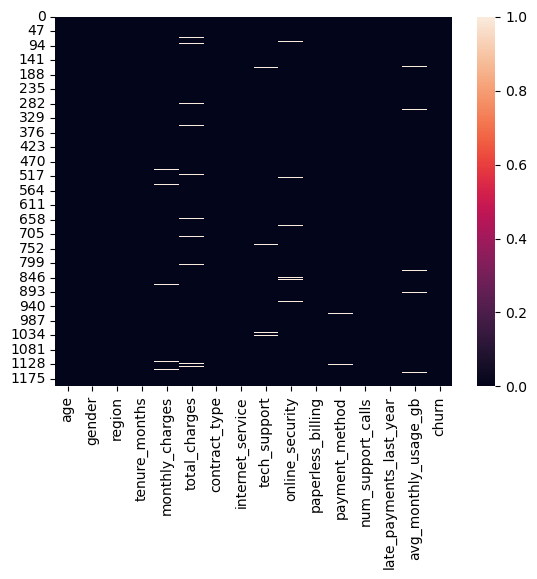

In [ ]:
sns.heatmap(df.isnull())

In [38]:
# duplicate records
df.duplicated().sum()

np.int64(20)

In [39]:
# unique values in categorical columns
df.nunique()

customer_id                1200
age                          63
gender                        2
region                        4
tenure_months                72
monthly_charges            1065
total_charges              1165
contract_type                 3
internet_service              3
tech_support                  3
online_security               3
paperless_billing             2
payment_method                4
num_support_calls             9
late_payments_last_year       7
avg_monthly_usage_gb        884
churn                         2
dtype: int64

In [40]:
# class distribution of the churn target
df['churn'].value_counts()
# # correlation matrix
# df.corr()
# # heatmap of the correlation matrix
# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
# plt.show()

churn
Yes    688
No     532
Name: count, dtype: int64

## 4. Data Cleaning


**Cleaning decisions (based on Section 3 findings):**

1. **Duplicate records:** There are 20 duplicate rows. I will **drop** them so the same customer is not counted twice during training.

2. **Missing numeric values:** `monthly_charges`, `total_charges`, and `avg_monthly_usage_gb` have missing values. I will fill them with the **median**, because median is less affected by outliers than the mean.

3. **Missing categorical values:** `tech_support`, `online_security`, and `payment_method` have missing values. I will fill them with the **mode** (most frequent value), which is suitable for categorical columns.

4. **`customer_id`:** This is only an identifier, not a behaviour feature. I will **remove** it so the model learns patterns instead of memorising IDs.


In [41]:
# remove duplicate records
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Duplicates before: 20
Duplicates after: 0
Shape after removing duplicates: (1200, 17)


In [42]:
# customer_id is only an identifier, not useful for prediction
df = df.drop("customer_id", axis=1)
df.head()


,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [54]:
# check mean median and mode for all missing numeric data
numeric_missing_cols = ["monthly_charges", "total_charges", "avg_monthly_usage_gb"]

for col in numeric_missing_cols:
    print(f"\n{col}")
    print("  mean  :", df[col].mean())
    print("  median:", df[col].median())
    print("  mode  :", df[col].mode()[0])



monthly_charges
  mean  : 66.56032230703985
  median: 69.27
  mode  : 18.0

total_charges
  mean  : 2422.769391602399
  median: 2120.45
  mode  : 12.6

avg_monthly_usage_gb
  mean  : 214.3494047619048
  median: 206.5
  mode  : 0.0


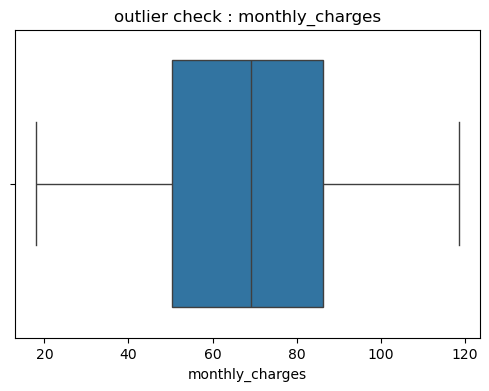

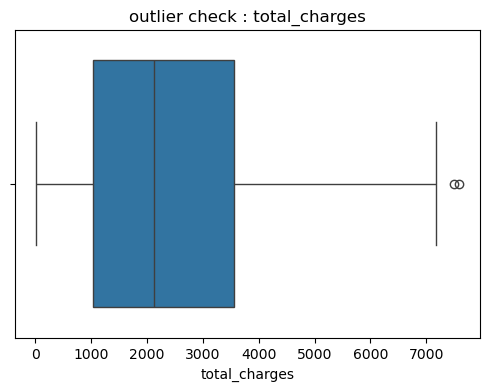

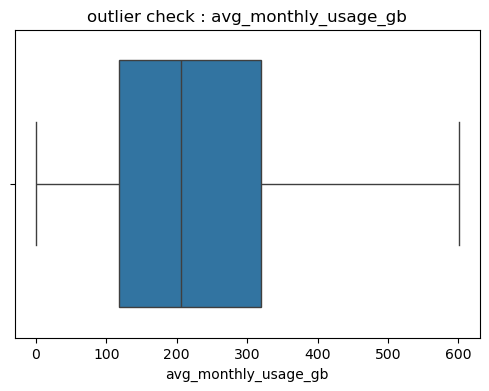

In [58]:
# visual outlier check for numeric columns with missing values

for col in ["monthly_charges", "total_charges", "avg_monthly_usage_gb"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'outlier check : {col}')
    plt.show



In [57]:
# fill missing numeric values with median
df["monthly_charges"].fillna(df["monthly_charges"].median(), inplace=True)
df["total_charges"].fillna(df["total_charges"].median(), inplace=True)
df["avg_monthly_usage_gb"].fillna(df["avg_monthly_usage_gb"].median(), inplace=True)


In [ ]:
# fill missing categorical values with mode
df["tech_support"].fillna(df["tech_support"].mode()[0], inplace=True)
df["online_security"].fillna(df["online_security"].mode()[0], inplace=True)
df["payment_method"].fillna(df["payment_method"].mode()[0], inplace=True)


In [ ]:
# check missing values after cleaning
df.isnull().sum()


In [ ]:
# final shape after cleaning
df.shape


## 5. Exploratory Data Analysis


### Churn class distribution


In [ ]:
# churn class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn")
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


**Observation:** The dataset has more churned customers (Yes) than non-churned (No), but the gap is not extreme. Accuracy alone may still hide mistakes on one class, so Precision, Recall, and F1 should also be checked later.


### Churn by contract type


In [ ]:
# churn by contract type
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="contract_type", hue="churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()


**Observation:** Month-to-month contracts usually show higher churn because customers can leave easily. Longer contracts (One year / Two year) often have lower churn.


### Churn by internet service


In [ ]:
# churn by internet service
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="internet_service", hue="churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()


**Observation:** Fiber optic customers often churn more than DSL or No internet customers. This can be linked to higher bills or higher service expectations.


### Monthly charges distribution


In [ ]:
# monthly charges distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="monthly_charges", kde=True)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()


**Observation:** Monthly charges are spread across a wide range. Higher monthly bills can increase the chance of churn if customers feel they are not getting enough value.


### Tenure distribution


In [ ]:
# tenure distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="tenure_months", kde=True)
plt.title("Tenure Distribution (Months)")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")
plt.show()


**Observation:** Many customers have shorter tenure. Newer customers are often more likely to leave before they become loyal long-term users.


### Additional visualization: Late payments vs churn


In [ ]:
# additional visualization: late payments vs churn
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="churn", y="late_payments_last_year")
plt.title("Late Payments Last Year vs Churn")
plt.xlabel("Churn")
plt.ylabel("Late Payments Last Year")
plt.show()


**Observation:** Customers who churn tend to have more late payments. Payment problems are a useful early warning signal for churn risk.


## 6. Prepare Features and Target


In [ ]:
# X = input features, y = target
X = df.drop("churn", axis=1)
y = df["churn"]


In [ ]:
X.head()


In [ ]:
y.head()


In [ ]:
# numeric columns
numeric_cols = X.select_dtypes(include=["number"]).columns
print("Numeric columns:")
print(numeric_cols.tolist())

# categorical columns
categorical_cols = X.select_dtypes(exclude=["number"]).columns
print("\nCategorical columns:")
print(categorical_cols.tolist())


## 7. Train-Test Split


In [ ]:
# split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
